# EX 4B – Baseball Databank

Same filtering, sorting, grouping, correlation and visualization structure as the friend's EX 4B, adapted to Baseball team-season statistics.

In [1]:
from pathlib import Path

def find_data(filename):
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("../data") / filename,
        Path("../../data") / filename,
        Path("/content") / filename,
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"{filename} not found. Upload the Baseball Databank CSV or keep it in the repository data folder.")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(find_data("Teams.csv"))

print("Baseball team-season dataset loaded successfully")
print("Shape:", df.shape)
display(df.head())

Baseball team-season dataset loaded successfully
Shape: (2805, 48)


,yearID,lgID,teamID,franchID,divID,Rank,G,Ghome,W,L,DivWin,WCWin,LgWin,WSWin,R,AB,H,2B,3B,HR,BB,SO,SB,CS,HBP,SF,RA,ER,ERA,CG,SHO,SV,IPouts,HA,HRA,BBA,SOA,E,DP,FP,name,park,attendance,BPF,PPF,teamIDBR,teamIDlahman45,teamIDretro
0,1871,NaN,BS1,BNA,NaN,3,31,NaN,20,10,NaN,NaN,N,NaN,401,1372,426,70,37,3,60,19.0,73.0,NaN,NaN,NaN,303,109,3.55,22,1,3,828,367,2,42,23,225,NaN,0.83,Boston Red Stockings,South End Grounds I,NaN,103,98,BOS,BS1,BS1
1,1871,NaN,CH1,CNA,NaN,2,28,NaN,19,9,NaN,NaN,N,NaN,302,1196,323,52,21,10,60,22.0,69.0,NaN,NaN,NaN,241,77,2.76,25,0,1,753,308,6,28,22,218,NaN,0.82,Chicago White Stockings,Union Base-Ball Grounds,NaN,104,102,CHI,CH1,CH1
2,1871,NaN,CL1,CFC,NaN,8,29,NaN,10,19,NaN,NaN,N,NaN,249,1186,328,35,40,7,26,25.0,18.0,NaN,NaN,NaN,341,116,4.11,23,0,0,762,346,13,53,34,223,NaN,0.81,Cleveland Forest Citys,National Association Grounds,NaN,96,100,CLE,CL1,CL1
3,1871,NaN,FW1,KEK,NaN,7,19,NaN,7,12,NaN,NaN,N,NaN,137,746,178,19,8,2,33,9.0,16.0,NaN,NaN,NaN,243,97,5.17,19,1,0,507,261,5,21,17,163,NaN,0.80,Fort Wayne Kekiongas,Hamilton Field,NaN,101,107,KEK,FW1,FW1
4,1871,NaN,NY2,NNA,NaN,5,33,NaN,16,17,NaN,NaN,N,NaN,302,1404,403,43,21,1,33,15.0,46.0,NaN,NaN,NaN,313,121,3.72,32,1,0,879,373,7,42,22,227,NaN,0.83,New York Mutuals,Union Grounds (Brooklyn),NaN,90,88,NYU,NY2,NY2


In [2]:
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)

Column names:
['yearID', 'lgID', 'teamID', 'franchID', 'divID', 'Rank', 'G', 'Ghome', 'W', 'L', 'DivWin', 'WCWin', 'LgWin', 'WSWin', 'R', 'AB', 'H', '2B', '3B', 'HR', 'BB', 'SO', 'SB', 'CS', 'HBP', 'SF', 'RA', 'ER', 'ERA', 'CG', 'SHO', 'SV', 'IPouts', 'HA', 'HRA', 'BBA', 'SOA', 'E', 'DP', 'FP', 'name', 'park', 'attendance', 'BPF', 'PPF', 'teamIDBR', 'teamIDlahman45', 'teamIDretro']

Data types:
yearID              int64
lgID               object
teamID             object
franchID           object
divID              object
Rank                int64
G                   int64
Ghome             float64
W                   int64
L                   int64
DivWin             object
WCWin              object
LgWin              object
WSWin              object
R                   int64
AB                  int64
H                   int64
2B                  int64
3B                  int64
HR                  int64
BB                  int64
SO                float64
SB                float64
CS  

In [3]:
print("Statistical summary:")
display(df[["yearID","G","W","L","R","RA","HR","ERA"]].describe().round(2))

Statistical summary:


,yearID,G,W,L,R,RA,HR,ERA
count,2805.00,2805.00,2805.00,2805.00,2805.00,2805.00,2805.00,2805.00
mean,1955.04,150.35,74.75,74.75,681.95,681.95,101.14,3.81
std,41.52,23.23,17.64,17.38,135.74,134.91,61.47,0.76
min,1871.00,6.00,0.00,4.00,24.00,34.00,0.00,1.22
25%,1919.00,153.00,66.00,65.00,613.00,609.00,42.00,3.34
50%,1963.00,157.00,77.00,76.00,690.00,688.00,107.00,3.82
75%,1992.00,162.00,87.00,87.00,763.00,764.00,149.00,4.30
max,2015.00,165.00,116.00,134.00,1220.00,1252.00,264.00,8.00


In [4]:
filtered = df[(df["yearID"] >= 2000) & (df["R"] >= 700)]
print("Team-seasons from 2000 onward scoring 700 or more runs:")
print(filtered[["yearID","teamID","name","W","R","RA"]].head(10).to_string(index=False))

Team-seasons from 2000 onward scoring 700 or more runs:
 yearID teamID                 name  W   R  RA
   2000    ANA       Anaheim Angels 82 864 869
   2000    ARI Arizona Diamondbacks 85 792 754
   2000    ATL       Atlanta Braves 95 810 714
   2000    BAL    Baltimore Orioles 74 794 913
   2000    BOS       Boston Red Sox 85 792 745
   2000    CHA    Chicago White Sox 95 978 839
   2000    CHN         Chicago Cubs 65 764 904
   2000    CIN      Cincinnati Reds 85 825 765
   2000    CLE    Cleveland Indians 90 950 816
   2000    COL     Colorado Rockies 82 968 897


In [5]:
print("Top teams by total wins:")
display(df.groupby("name")["W"].sum().sort_values(ascending=False).head(10))

Top teams by total wins:


name
Pittsburgh Pirates       9800
Cincinnati Reds          9427
St. Louis Cardinals      9390
New York Yankees         9266
Detroit Tigers           9085
Philadelphia Phillies    9012
Chicago White Sox        9004
Chicago Cubs             8867
Boston Red Sox           8696
Cleveland Indians        8037
Name: W, dtype: int64

In [6]:
print("Year-wise total runs:")
display(df.groupby("yearID")["R"].sum().tail(10))

Year-wise total runs:


yearID
2006    23599
2007    23322
2008    22585
2009    22419
2010    21308
2011    20808
2012    21017
2013    20255
2014    19761
2015    20647
Name: R, dtype: int64

In [7]:
print("Correlation matrix:")
display(df[["yearID","G","W","L","R","RA","HR","ERA"]].corr().round(2))

Correlation matrix:


,yearID,G,W,L,R,RA,HR,ERA
yearID,1.00,0.60,0.42,0.43,0.27,0.28,0.84,0.37
G,0.60,1.00,0.68,0.66,0.53,0.51,0.52,0.17
W,0.42,0.68,1.00,-0.10,0.68,0.01,0.48,-0.22
L,0.43,0.66,-0.10,1.00,0.03,0.69,0.25,0.48
R,0.27,0.53,0.68,0.03,1.00,0.55,0.50,0.32
RA,0.28,0.51,0.01,0.69,0.55,1.00,0.35,0.80
HR,0.84,0.52,0.48,0.25,0.50,0.35,1.00,0.42
ERA,0.37,0.17,-0.22,0.48,0.32,0.80,0.42,1.00


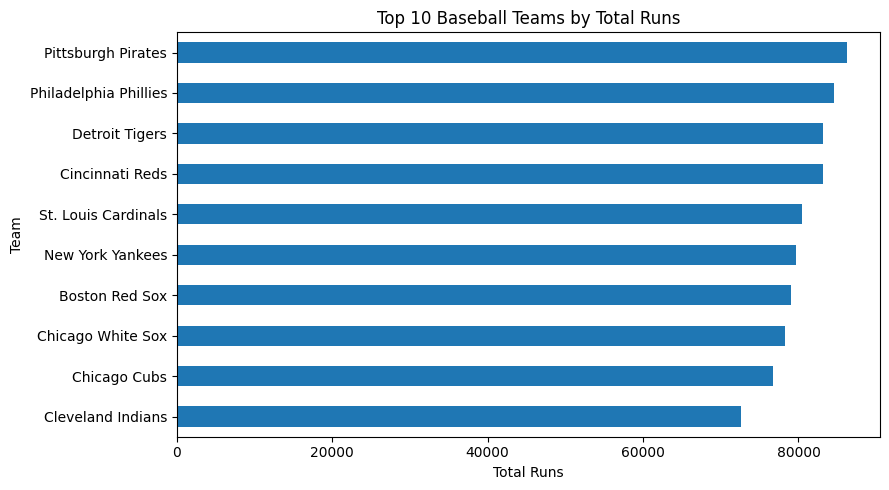

In [8]:
plt.figure(figsize=(9,5))
df.groupby("name")["R"].sum().nlargest(10).sort_values().plot(kind="barh")
plt.title("Top 10 Baseball Teams by Total Runs")
plt.xlabel("Total Runs")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

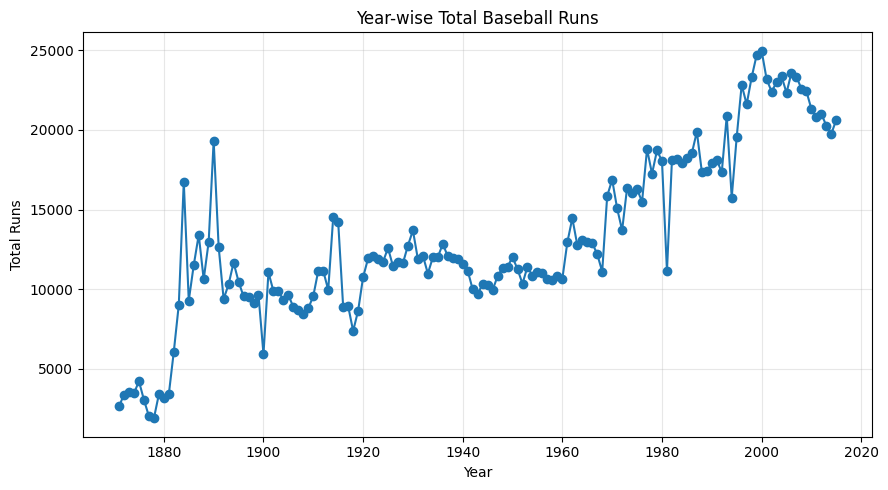

In [9]:
year_runs = df.groupby("yearID")["R"].sum()
plt.figure(figsize=(9,5))
plt.plot(year_runs.index, year_runs.values, marker="o")
plt.title("Year-wise Total Baseball Runs")
plt.xlabel("Year")
plt.ylabel("Total Runs")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()